In [1]:
%pip install torchsummary

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
import matplotlib.pyplot as plt
from torchsummary import summary
import os

In [3]:
num_cpu =  os.cpu_count()
print('number of cpu:', num_cpu)

number of cpu: 4


In [4]:
import torchvision.transforms as transforms
from torchvision import datasets

mean = torch.Tensor([0.4914, 0.4822, 0.4465])
std = torch.Tensor([0.2023, 0.1994, 0.2010])

transform_train = transforms.Compose([     
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std) 
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std) 
])

train_dataset = datasets.CIFAR10(
    root='/kaggle/temp/',
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = datasets.CIFAR10(
    root='/kaggle/temp/',
    train=False,
    download=True,
    transform=transform_test
)

print('number of training samples:', len(train_dataset))
print('number of testing samples:', len(test_dataset))

100%|██████████| 170M/170M [00:03<00:00, 44.7MB/s] 


number of training samples: 50000
number of testing samples: 10000


In [5]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=num_cpu)
test_loader = DataLoader(test_dataset, batch_size=32, num_workers=num_cpu)

In [6]:
def imshow(img):
    img = img * std.unsqueeze(1).unsqueeze(2) + mean.unsqueeze(1).unsqueeze(2)
    plt.imshow(np.transpose(img, (1, 2, 0)))
    plt.axis('off')
    plt.show()

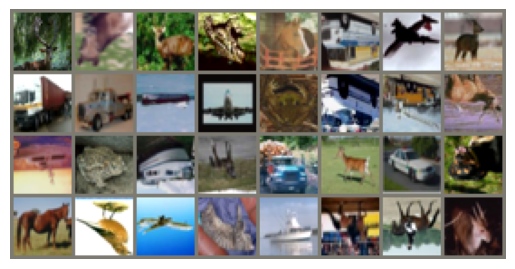

deer, horse, deer, frog, horse, truck, airplane, deer, truck, truck, ship, airplane, frog, automobile, truck, deer, ship, frog, ship, horse, truck, deer, automobile, dog, horse, bird, airplane, cat, ship, horse, horse, deer


In [7]:
from torchvision.utils import make_grid

images, labels = next(iter(train_loader))
imshow(make_grid(images))
print(', '.join(f'{train_loader.dataset.classes[labels[i]]}' for i in range(len(labels))))

In [8]:
print('batch-image shape:', images.shape)
print('number of classes:', len(train_dataset.classes))

batch-image shape: torch.Size([32, 3, 32, 32])
number of classes: 10


In [9]:
def conv_block(in_channels, out_channels, pool=False):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1), 
              nn.BatchNorm2d(out_channels), 
              nn.ReLU()]
    if pool:
        layers.append(nn.MaxPool2d(kernel_size=2, stride=1))
        
    return nn.Sequential(*layers)

In [10]:
class ResNet9(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.conv1 = conv_block(in_channels, 64)
        self.conv2 = conv_block(64, 128, pool=True)
        self.res1 = nn.Sequential(conv_block(128, 128), conv_block(128, 128))

        self.conv3 = conv_block(128, 256, pool=True)
        self.conv4 = conv_block(256, 512, pool=True)
        self.res2 = nn.Sequential(conv_block(512, 512), conv_block(512, 512))

        self.classifier = nn.Sequential(nn.AdaptiveMaxPool2d((1,1)),
                                        nn.Flatten(),
                                        nn.Dropout(0.2),
                                        nn.Linear(512, num_classes))
                                        
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.res1(x) + x

        x = self.conv3(x)
        x = self.conv4(x)
        x = self.res2(x) + x

        x = self.classifier(x)

        return x

In [11]:
def init_weights(layer):
    if isinstance(layer, nn.Conv2d):
        nn.init.kaiming_normal_(layer.weight, mode='fan_out', nonlinearity='relu')
    elif isinstance(layer, nn.Linear):
        nn.init.xavier_normal_(layer.weight)

In [12]:
import torch._dynamo

torch._dynamo.config.suppress_errors = True

model = ResNet9(3, 10)
model.apply(init_weights)
model.cuda()

summary(model, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
            Conv2d-4          [-1, 128, 32, 32]          73,856
       BatchNorm2d-5          [-1, 128, 32, 32]             256
              ReLU-6          [-1, 128, 32, 32]               0
         MaxPool2d-7          [-1, 128, 31, 31]               0
            Conv2d-8          [-1, 128, 31, 31]         147,584
       BatchNorm2d-9          [-1, 128, 31, 31]             256
             ReLU-10          [-1, 128, 31, 31]               0
           Conv2d-11          [-1, 128, 31, 31]         147,584
      BatchNorm2d-12          [-1, 128, 31, 31]             256
             ReLU-13          [-1, 128, 31, 31]               0
           Conv2d-14          [-1, 256,

In [13]:
import torch.optim as optim

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.RAdam(model.parameters(), lr=3e-3, weight_decay=1e-6, decoupled_weight_decay=True, foreach=True)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.925)

In [14]:
import time

num_epochs = 25

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start_time = time.time()

for epoch in range(num_epochs):
    epoch_train_loss = 0
    epoch_val_loss = 0
    epoch_train_corrects = 0
    epoch_val_corrects = 0

    model.train()
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.cuda(), targets.cuda()
        
        outputs = model(inputs)
        
        preds = torch.argmax(outputs, dim=1)
        
        loss = loss_fn(outputs, targets)
        epoch_train_loss += loss.item() * inputs.size(0)
        epoch_train_corrects += torch.sum(preds == targets.data).float()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    scheduler.step()

    epoch_train_loss /= len(train_dataset)
    epoch_train_accuracy = epoch_train_corrects / len(train_dataset)
    
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy.cpu())

    model.eval()
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.cuda(), targets.cuda()
            
            val_outputs = model(inputs)
            
            val_preds = torch.argmax(val_outputs, dim=1)
            
            val_loss = loss_fn(val_outputs, targets)
            epoch_val_loss += val_loss.item() * inputs.size(0)
            epoch_val_corrects += torch.sum(val_preds == targets.data).float()

    epoch_val_loss /= len(test_dataset)
    epoch_val_accuracy = epoch_val_corrects / len(test_dataset)
    
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy.cpu())

    print("Epoch {}/{}: Train Loss = {:.4f}, Val Loss = {:.4f}, Train Acc = {:.4f}, Val Acc = {:.4f}".format(
        epoch + 1, num_epochs, train_losses[-1], val_losses[-1], train_accuracies[-1], val_accuracies[-1]))

end_time = time.time()

training_time = end_time - start_time

print("training time: {:.2f}s".format(training_time))

Epoch 1/25: Train Loss = 2.1394, Val Loss = 1.4272, Train Acc = 0.3292, Val Acc = 0.4966
Epoch 2/25: Train Loss = 1.3851, Val Loss = 1.3556, Train Acc = 0.5031, Val Acc = 0.5062
Epoch 3/25: Train Loss = 1.1519, Val Loss = 1.0071, Train Acc = 0.5886, Val Acc = 0.6408
Epoch 4/25: Train Loss = 1.0147, Val Loss = 0.9371, Train Acc = 0.6381, Val Acc = 0.6654
Epoch 5/25: Train Loss = 0.9165, Val Loss = 0.8178, Train Acc = 0.6746, Val Acc = 0.7074
Epoch 6/25: Train Loss = 0.8322, Val Loss = 0.7157, Train Acc = 0.7080, Val Acc = 0.7449
Epoch 7/25: Train Loss = 0.7480, Val Loss = 0.6863, Train Acc = 0.7385, Val Acc = 0.7563
Epoch 8/25: Train Loss = 0.6884, Val Loss = 0.6490, Train Acc = 0.7597, Val Acc = 0.7744
Epoch 9/25: Train Loss = 0.6282, Val Loss = 0.6116, Train Acc = 0.7793, Val Acc = 0.7876
Epoch 10/25: Train Loss = 0.5833, Val Loss = 0.5433, Train Acc = 0.7960, Val Acc = 0.8115
Epoch 11/25: Train Loss = 0.5475, Val Loss = 0.5862, Train Acc = 0.8104, Val Acc = 0.7978
Epoch 12/25: Train 

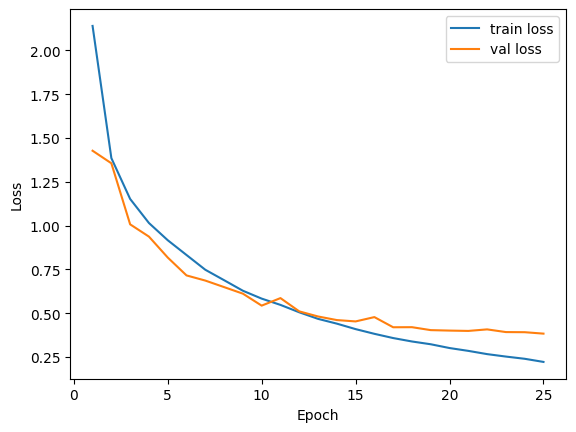

In [15]:
plt.plot(range(1, num_epochs + 1), train_losses, label="train loss")
plt.plot(range(1, num_epochs + 1), val_losses, label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

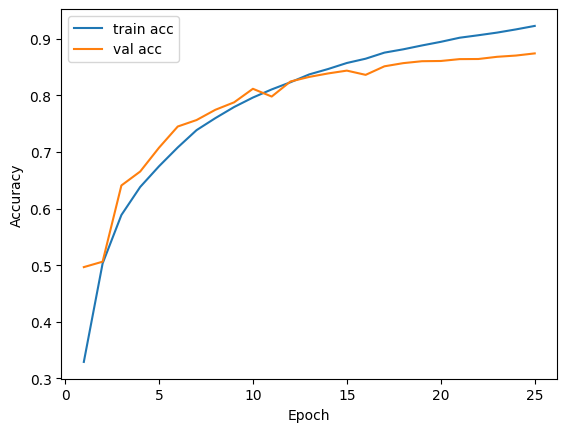

In [16]:
plt.plot(range(1, num_epochs + 1), train_accuracies, label="train acc")
plt.plot(range(1, num_epochs + 1), val_accuracies, label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [17]:
y_test = []
y_pred = []

model.eval()

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.cuda()
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        y_test.append(targets)
        y_pred.append(preds)

y_test = torch.cat(y_test).cpu()
y_pred = torch.cat(y_pred).cpu()

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy score: {:.4f}".format(accuracy_score(y_test, y_pred)))
print("Precision score: {:.4f}".format(precision_score(y_test, y_pred, average='weighted')))
print("Recall score: {:.4f}".format(recall_score(y_test, y_pred, average='weighted')))
print("F1 score: {:.4f}".format(f1_score(y_test, y_pred, average='weighted')))

Accuracy score: 0.8740
Precision score: 0.8736
Recall score: 0.8740
F1 score: 0.8735


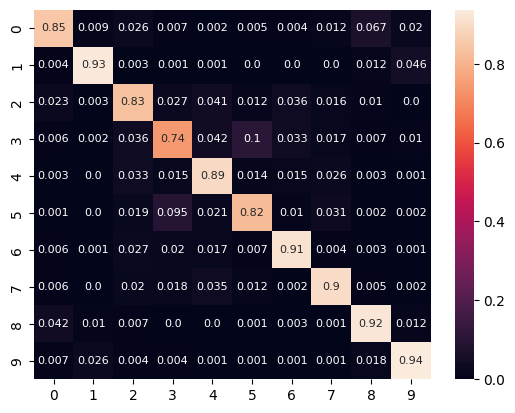

In [19]:
import seaborn as sb
from sklearn.metrics import confusion_matrix

cfm = confusion_matrix(y_test, y_pred)

sb.heatmap(cfm / np.sum(cfm, axis=1), annot=True, fmt=".2", annot_kws={"size": 8})
plt.show()

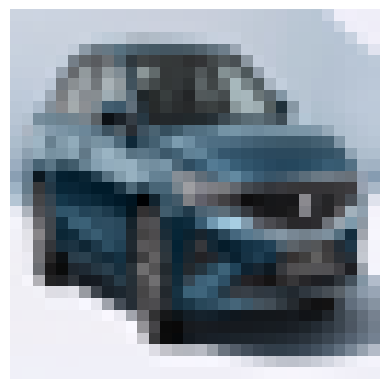

image shape: (32, 32, 3)


In [20]:
from PIL import Image

image = Image.open('/kaggle/input/testing/test.jpg')
image = image.resize((32, 32))
image = np.array(image)
plt.imshow(image)
plt.axis('off')
plt.show()
print('image shape:', image.shape)

In [21]:
image = transform_test(image)
image = image.unsqueeze(0)
image = image.cuda()

In [22]:
model.eval()

with torch.no_grad():
    output = model(image)
    prediction = torch.argmax(output, dim=1)
    
print('The predicted object is', test_loader.dataset.classes[prediction])

The predicted object is automobile


In [23]:
torch.save(model.state_dict(), '/kaggle/working/resnet9.pth')